In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
import statsmodels.api as sm
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
# from patsy import dmatrix
from datetime import datetime
from datetime import timedelta
import datetime
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm
import warnings
from dateutil.relativedelta import relativedelta
from dateutil import parser
from itertools import combinations
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings("ignore")

# Regression Model

In [ ]:
def data_pipeline(start_date = '2023-10-01', end_date='2023-10-31'):
    # Function call to process the tradewed data file
    def data_preprocess(filename):
        rawdata = pd.read_csv(filename)
        rawdata = rawdata.loc[rawdata['ACCEPTEDVOL'] != 0] # Ignore trade stamps with zero volume
        # Remove BILLs , STRIPs and TRSY FRN data to skip the computation from yield to price for Bills and negative spreads for Strips + Treasury FRN
        substring = 'Bill'
        substring2 = 'Strip'
        substring3 = 'TRSY FRN'
        substring4 = 'TIPS'
        filter = rawdata['MATURITY_RANGE'].str.contains(substring)
        rawdata = rawdata[~filter]
        filter2 = rawdata['MATURITY_RANGE'].str.contains(substring2)
        rawdata = rawdata[~filter2]
        filter3 = rawdata['MATURITY_RANGE'].str.contains(substring3)
        rawdata = rawdata[~filter3]
        filter4 = rawdata['MATURITY_RANGE'].str.contains(substring4)
        rawdata = rawdata[~filter4]
        rawdata = rawdata.loc[rawdata['TRADETYPE'] == 'OUTRIGHT'] # Only consider outright trades
        rawdata.reset_index(inplace=True)
        rawdata['TIMESTAMP'] = pd.to_datetime(rawdata['TRADETIME'].str.rstrip(' Z'), format='%Y-%m-%d %H:%M:%S.%f')
        rawdata['TRADEDATE'] = pd.to_datetime(rawdata['TRADEDATE'], format='%m/%d/%y')
        rawdata['MATURITY_DATE'] = pd.to_datetime(rawdata['MATURITY_DATE'], format='%m/%d/%y')
        rawdata.set_index('TIMESTAMP', inplace= True)
        rawdata.sort_index(inplace=True)
        return rawdata

    # Function to filter on date range
    def filter_date_range(df, start_date, end_date):
        filtered_df = df[(df.index >= start_date) & (df.index <= end_date)]
        return filtered_df
    # from google.colab import drive
    # drive.mount('/content/drive')
    # import os
    # os.chdir('/content/drive/MyDrive/blockhouse/TCA')
    # tw1 = data_preprocess('data/Blockhouse Data 1.csv')
    # tw2 = data_preprocess('data/Blockhouse Data 2.csv')
    # tw3 = data_preprocess('data/Blockhouse Data 3.csv')
    # tw4 = data_preprocess('data/Blockhouse Data 4.csv')
    tw1 = data_preprocess('/content/Blockhouse Data 1.csv')
    tw2 = data_preprocess('/content/Blockhouse Data 2.csv')
    tw3 = data_preprocess('/content/Blockhouse Data 3.csv')
    tw4 = data_preprocess('/content/Blockhouse Data 4.csv')
    rawdata = pd.concat([tw1, tw2, tw3, tw4], axis =0)
    filtered_rawdata = rawdata[['DEALER', 'ACCEPTEDVOL', 'PRICE', 'INSTRUMENT', 'MATURITY_RANGE','MATURITY_DATE', 'TRADEDATE',"COUPON_RATE",'SIDE','COMP_ASK','COMP_BID']].copy()

    #only choose data within some period for regression
    filtered_rawdata = filter_date_range(filtered_rawdata, start_date, end_date)

    # Calculate mid price, slippage, and spread
    filtered_rawdata['MID_PRICE'] = (filtered_rawdata['COMP_ASK'] + filtered_rawdata['COMP_BID']) / 2
    filtered_rawdata['SLIPPAGE'] = filtered_rawdata.apply(lambda row: row['PRICE'] - row['MID_PRICE'] if row['SIDE'] == 'BUY' else row['MID_PRICE'] - row['PRICE'], axis=1)
    filtered_rawdata['Spread'] = (filtered_rawdata['COMP_ASK'] - filtered_rawdata['COMP_BID'])/2
    filtered_rawdata['Spread1'] = (filtered_rawdata['COMP_ASK'] - filtered_rawdata['COMP_BID'])/filtered_rawdata['MID_PRICE']
    # remove the sample with negative spread value
    filtered_rawdata = filtered_rawdata[filtered_rawdata['Spread'] >= 0]

    # for specific maturity range
    filtered_rawdata.sort_values(by='TIMESTAMP', inplace=True)
    return filtered_rawdata

def feature_engineering(maturity_range, filtered_rawdata, features,frequency):
    # remove features' outlier
    def remove_outliers_zscore(df, feature , threshold=1.96):
        mean = df[feature].mean()
        std_dev = df[feature].std()
        z_scores = (df[feature] - mean) / std_dev
        return df[(z_scores >= -threshold) & (z_scores <= threshold)]

    group1 = filtered_rawdata[(filtered_rawdata['MATURITY_RANGE'] == maturity_range)]
    # Fuction to remove outliers based on Z-score
    group1 = remove_outliers_zscore(group1,'Spread')
    group1 = remove_outliers_zscore(group1, 'Spread')


    # concentrate data from samples to one minute based dataframe(final dataframe for regession)
    def feature_engineering(group_data):
        group = group_data.copy()
        ytm = []
        for i in range(0, group.shape[0]):
            ytm.append(relativedelta(group['MATURITY_DATE'].iloc[i], group['TRADEDATE'].iloc[i]).years)
        group['Years to Maturity'] = ytm
        group['BUY_SELL'] = group['SIDE'].map({'BUY': 1, 'SELL': 0})

        # Resample the data for Regression Analysis
        group['Volatility'] = np.log(group['PRICE'].pct_change() + 1)
        data_resampled = group.resample(frequency).agg({
            'PRICE': 'mean',  # You can choose different aggregation methods like 'sum', 'max', 'min', etc.
            'Volatility': 'std',
            'ACCEPTEDVOL': 'sum',
            'Years to Maturity': 'mean',
            'Spread': 'mean',
            'Spread1': 'mean',
            'DEALER': 'nunique',
            'INSTRUMENT': 'nunique',
            'BUY_SELL': 'mean'

        })
        data_resampled.dropna(inplace=True)
        data_resampled.rename(
            columns={'ACCEPTEDVOL': 'Total_Volume', 'DEALER': 'DEALER_COUNT', 'INSTRUMENT': 'INSTRUMENT_COUNT',
                     'BUY_SELL': 'BUY_VOLUME/TOTAL'}, inplace=True)
        data_resampled['Trading Activity'] = np.log1p(data_resampled['INSTRUMENT_COUNT'])
        data_resampled['Log(Total_Volume)'] = np.log(data_resampled['Total_Volume'])
        data_resampled['Total_Volume_change'] = data_resampled['Total_Volume'].pct_change()
        data_resampled.dropna(inplace=True)
        # calculate the log of percentage of change's volatility and mean
        Volatility = group.groupby('INSTRUMENT')['PRICE'].pct_change().reset_index()
        Volatility['PRICE1'] = np.log(Volatility['PRICE'] + 1)
        Volatility['PRICE2'] = np.log(Volatility['PRICE'] + 1)
        Volatility.dropna(inplace=True)
        Volatility.set_index('TIMESTAMP', inplace=True)
        Volatility = Volatility.resample('1T').agg({
            'PRICE1': 'std', 'PRICE2': 'mean'}).fillna(0)
        Volatility.rename(columns={'PRICE1': 'Pct_change_vol', 'PRICE2': 'Pct_change_mean'}, inplace=True)
        Volatility.reset_index()

        # # calculate the buy accepted volumne/all accepted volumne to evaluate the activity of buy side market.
        # pivot = group.pivot_table(index=pd.Grouper(freq='T'), columns='SIDE', values='ACCEPTEDVOL', aggfunc='sum')
        # pivot.fillna(0, inplace=True)
        # pivot['Buy/(Buy+Sell) Ratio'] = pivot['BUY'] / (pivot['SELL'] + pivot['BUY'])
        # pivot = pivot.reset_index()[['TIMESTAMP', 'Buy/(Buy+Sell) Ratio']]

        data_resampled = data_resampled.reset_index()
        pd.merge(data_resampled, Volatility, on='TIMESTAMP', how='left')
        # pd.merge(data_resampled, pivot, on='TIMESTAMP', how='left')
        data_resampled.set_index('TIMESTAMP', inplace=True)
        data_resampled = remove_outliers_zscore(data_resampled, 'Log(Total_Volume)')
        data_resampled = remove_outliers_zscore(data_resampled, 'Total_Volume_change')
        return data_resampled

    data_resampled_1 = feature_engineering(group1)
    data_resampled_1.reset_index(inplace=True)
    data_resampled_1.dropna(inplace=True)

    # do scaler.
    scaler = StandardScaler()
    for feature in features:
        data_resampled_1[feature] = scaler.fit_transform(data_resampled_1[[feature]])
    return data_resampled_1


# regression construction
def get_regression_model(data_resampled_1,features):
    X = data_resampled_1[features]
    y = data_resampled_1['Spread1']
    X = sm.add_constant(X)
    model1 = sm.OLS(y, X).fit()
    return model1

In [ ]:
filtered_rawdata1

,DEALER,ACCEPTEDVOL,PRICE,INSTRUMENT,MATURITY_RANGE,MATURITY_DATE,TRADEDATE,COUPON_RATE,SIDE,COMP_ASK,COMP_BID,MID_PRICE,SLIPPAGE,Spread,Spread1
TIMESTAMP,,,,,,,,,,,,,,,
2023-10-02 06:47:43,D28,297.95,89.461106,91282CDG3,Note 1.5 - 3.5 Year,2026-10-31,2023-10-02,1.125,BUY,89.488281,89.433594,89.460938,0.000168,0.027344,0.000611
2023-10-02 06:47:43,D28,436.32,73.531450,912810RP5,Note >10 Year,2045-11-15,2023-10-02,3.000,BUY,73.632812,73.460938,73.546875,-0.015425,0.085938,0.002337
2023-10-02 06:47:43,D69,1100.90,99.761887,91282CJA0,Note 3.5 - 5.5 Year,2028-09-30,2023-10-02,4.625,BUY,99.769531,99.753906,99.761719,0.000168,0.007812,0.000157
2023-10-02 06:47:43,D38,676.70,90.133013,912810TT5,Note >10 Year,2053-08-15,2023-10-02,4.125,BUY,90.160156,90.128906,90.144531,-0.011519,0.015625,0.000347
2023-10-02 06:47:43,D38,3939.00,99.691574,91282CHV6,Note 1.5 - 3.5 Year,2025-08-31,2023-10-02,5.000,BUY,99.703125,99.691406,99.697266,-0.005691,0.005859,0.000118
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-10-30 16:30:53,D7,14459.16,96.242356,9128285C0,Note 1.5 - 3.5 Year,2025-09-30,2023-10-30,3.000,BUY,96.273438,96.214844,96.244141,-0.001785,0.029297,0.000609
2023-10-30 16:37:05,D11,85597.50,91.062332,9128282R0,Note 3.5 - 5.5 Year,2027-08-15,2023-10-30,2.250,SELL,91.093750,91.039062,91.066406,0.004074,0.027344,0.000601
2023-10-30 16:41:53,D38,4040.00,83.289263,912810TS7,Note >10 Year,2043-05-15,2023-10-30,3.875,BUY,83.312500,83.265625,83.289062,0.000200,0.023438,0.000563


In [ ]:
start = '2023-10-01'
end = '2023-10-31'
feature = ['Volatility', 'Log(Total_Volume)', 'INSTRUMENT_COUNT', 'DEALER_COUNT']
filtered_rawdata1 = data_pipeline(start_date = start, end_date=end)
data = feature_engineering(maturity_range ='Note 5.5 - 10 Year', filtered_rawdata = filtered_rawdata1 , features = feature,frequency='1T')
model_1 = get_regression_model(data,feature)
model_1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                Spread1   R-squared:                       0.311
Model:                            OLS   Adj. R-squared:                  0.306
Method:                 Least Squares   F-statistic:                     67.19
Date:                Thu, 03 Oct 2024   Prob (F-statistic):           6.35e-47
Time:                        14:57:50   Log-Likelihood:                 4699.3
No. Observations:                 601   AIC:                            -9389.
Df Residuals:                     596   BIC:                            -9367.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.0004   3.98e-06    109.163      0.000       0.000       0.000
Volatility         2.918e-05   4.07e-06      7.173      0.000    2.12e-05    3.72e-05
Log(Total_Volume) -5.508e-05   4.14e-06    -13.291      0.000   -6.32e-05   -4.69e-05
INSTRUMENT_COUNT   2.981e-05   8.03e-06      3.711      0.000     1.4e-05    4.56e-05
DEALER_COUNT      -1.906e-05    7.9e-06     -2.414      0.016   -3.46e-05   -3.55e-06
==============================================================================
Omnibus:                       13.851   Durbin-Watson:                   1.891
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               14.252
Skew:                           0.347   Prob(JB):                     0.000804
Kurtosis:                       3.294   Cond. No.                         3.81
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Predict

We can use the predicted spread - actual spread to rank the dealers.

In [ ]:
def ranking(start_date_rank, end_date_rank,maturity_range,model1,feature,threshold = 100):
    filtered_rawdata2 = data_pipeline(start_date = start_date_rank, end_date=end_date_rank)
    filter_dealer = filtered_rawdata2[filtered_rawdata2.MATURITY_RANGE == maturity_range].groupby(['DEALER'])['ACCEPTEDVOL'].count()
    dealer_list = filter_dealer[filter_dealer>=threshold].reset_index()['DEALER']
    data_ranking = filtered_rawdata2[filtered_rawdata2.DEALER.isin(dealer_list)].groupby('DEALER').apply(
        lambda group: feature_engineering(
            maturity_range= maturity_range,
            filtered_rawdata=group,
            features=feature,
            frequency='1D'
        )
    )
    data_ranking_X = data_ranking[feature]
    data_ranking_y = data_ranking['Spread1']
    data_ranking_X = sm.add_constant(data_ranking_X)  # Don't forget to add the constant here as well
    predictions = model1.predict(data_ranking_X)
    ranking_data = pd.concat([predictions,data_ranking_y], axis=1).rename(columns={0:'Predicted_Spread','Spread1':'Actual_Spread'})
    ranking_data['Rank_value'] = ranking_data['Predicted_Spread'] - ranking_data['Actual_Spread']
    final_rank = ranking_data.groupby('DEALER')['Rank_value'].mean().reset_index()
    final_rank['Rank'] = final_rank['Rank_value'].rank(ascending=False)

    return final_rank.sort_values('Rank')

# Result & Ranking

In [ ]:
# 0 - 1.5 Year
start = '2023-10-01'
end = '2023-10-31'
feature = ['Volatility', 'Log(Total_Volume)','PRICE','INSTRUMENT_COUNT', 'DEALER_COUNT']
filtered_rawdata1 = data_pipeline(start_date = start, end_date=end)
data = feature_engineering(maturity_range ='Note 0 - 1.5 Year', filtered_rawdata = filtered_rawdata1 , features = feature,frequency='1T')
model_group1 = get_regression_model(data,feature)
ranking('2023-12-01', '2023-12-31','Note 0 - 1.5 Year',model_group1,feature,threshold = 100)

Predicted_Spread  Actual_Spread  Rank_value
DEALER                                                
D16    0           0.000449       0.000418    0.000031
       1           0.000467       0.000374    0.000094
       2           0.000447       0.000387    0.000060
       3           0.000462       0.000433    0.000029
       4           0.000458       0.000483   -0.000025
...                     ...            ...         ...
D74    11          0.000491       0.000477    0.000014
       12          0.000445       0.000577   -0.000132
       13          0.000450       0.000581   -0.000131
       14          0.000424       0.000509   -0.000085
       15          0.000430       0.000489   -0.000059

[239 rows x 3 columns]

In [ ]:
model_group1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                Spread1   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.8510
Date:                Wed, 04 Sep 2024   Prob (F-statistic):              0.357
Time:                        16:27:15   Log-Likelihood:                 4975.6
No. Observations:                 604   AIC:                            -9947.
Df Residuals:                     602   BIC:                            -9938.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005   2.61e-06    174.282      0.000       0.000       0.000
Volatility  2.406e-06   2.61e-06      0.923      0.357   -2.72e-06    7.53e-06
==============================================================================
Omnibus:                       10.077   Durbin-Watson:                   1.385
Prob(Omnibus):                  0.006   Jarque-Bera (JB):                7.019
Skew:                           0.132   Prob(JB):                       0.0299
Kurtosis:                       2.543   Cond. No.                         1.00
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
# 1.5 - 3.5 Year
start = '2023-10-01'
end = '2023-10-31'
feature = ['Volatility', 'Log(Total_Volume)', 'INSTRUMENT_COUNT', 'DEALER_COUNT']
filtered_rawdata1 = data_pipeline(start_date = start, end_date=end)
data = feature_engineering(maturity_range ='Note 1.5 - 3.5 Year', filtered_rawdata = filtered_rawdata1 , features = feature,frequency='1T')
model_group2 = get_regression_model(data,feature)
ranking('2023-12-01', '2023-12-31','Note 1.5 - 3.5 Year',model_group2,feature,threshold = 100)

,DEALER,Rank_value,Rank
7,D50,0.000219,1.0
13,D70,0.000154,2.0
0,D11,0.000152,3.0
12,D7,0.000150,4.0
3,D29,0.000138,5.0
9,D58,0.000112,6.0
6,D45,0.000094,7.0
14,D74,0.000074,8.0
10,D63,0.000065,9.0
1,D16,0.000062,10.0


In [ ]:
# 3.5 - 5.5 Year
start = '2023-10-01'
end = '2023-10-31'
feature = ['Volatility', 'Log(Total_Volume)', 'INSTRUMENT_COUNT', 'DEALER_COUNT']
filtered_rawdata1 = data_pipeline(start_date = start, end_date=end)
data = feature_engineering(maturity_range ='Note 3.5 - 5.5 Year', filtered_rawdata = filtered_rawdata1 , features = feature,frequency='1T')
model_group3 = get_regression_model(data,feature)
ranking('2023-12-01', '2023-12-31','Note 3.5 - 5.5 Year',model_group3,feature,threshold = 100)

,DEALER,Rank_value,Rank
2,D29,0.000123,1.0
5,D45,0.000090,2.0
8,D63,0.000033,3.0
1,D28,0.000024,4.0
4,D38,0.000022,5.0
0,D16,0.000005,6.0
9,D69,-0.000002,7.0
7,D54,-0.000040,8.0
10,D74,-0.000046,9.0
3,D36,-0.000047,10.0


In [ ]:
# 5.5 - 10 Year
start = '2023-10-01'
end = '2023-10-31'
feature = ['Volatility', 'Log(Total_Volume)', 'INSTRUMENT_COUNT', 'DEALER_COUNT']
filtered_rawdata1 = data_pipeline(start_date = start, end_date=end)
data = feature_engineering(maturity_range ='Note 5.5 - 10 Year', filtered_rawdata = filtered_rawdata1 , features = feature,frequency='1T')
model_group4 = get_regression_model(data,feature)
ranking('2023-12-01', '2023-12-31','Note 5.5 - 10 Year',model_group4,feature,threshold = 100)

,DEALER,Rank_value,Rank
1,D28,0.000105,1.0
5,D45,0.000085,2.0
2,D29,0.000072,3.0
7,D54,0.000070,4.0
10,D74,0.000057,5.0
4,D38,0.000051,6.0
8,D63,0.000048,7.0
3,D36,0.000034,8.0
9,D69,0.000032,9.0
0,D16,0.000004,10.0


In [ ]:
# >10 Year
start = '2023-10-01'
end = '2023-10-31'
feature = ['Volatility', 'Log(Total_Volume)','INSTRUMENT_COUNT', 'DEALER_COUNT']
filtered_rawdata1 = data_pipeline(start_date=start, end_date=end)
data = feature_engineering(maturity_range='Note >10 Year', filtered_rawdata=filtered_rawdata1, features=feature,
                           frequency='1T')
model_group5 = get_regression_model(data, feature)
ranking('2023-12-01', '2023-12-31', 'Note >10 Year', model_group5,feature,threshold=100)

,DEALER,Rank_value,Rank
8,D63,0.000838,1.0
0,D11,0.000541,2.0
3,D38,0.000447,3.0
5,D50,0.000402,4.0
10,D7,0.000365,5.0
4,D45,0.000361,6.0
1,D28,0.000316,7.0
6,D54,0.000296,8.0
11,D70,0.000272,9.0
2,D36,0.000266,10.0


# new new new

In [ ]:
import pandas as pd

def data_pipeline(start_date='2023-10-01', end_date='2023-10-31'):
    def data_preprocess(filename):
        # Load the CSV file
        rawdata = pd.read_csv(filename)

        # Ensure 'TRADETIME' column exists
        if 'TRADETIME' not in rawdata.columns:
            raise KeyError(f"'TRADETIME' column not found in {filename}")

        # Filter out rows with zero volume and other unwanted instruments
        rawdata = rawdata.loc[rawdata['ACCEPTEDVOL'] != 0]
        substring = 'Bill|Strip|TRSY FRN|TIPS'
        rawdata = rawdata[~rawdata['MATURITY_RANGE'].str.contains(substring)]
        rawdata = rawdata.loc[rawdata['TRADETYPE'] == 'OUTRIGHT']

        # Reset index and create TIMESTAMP column from TRADETIME
        rawdata.reset_index(inplace=True)
        try:
            rawdata['TIMESTAMP'] = pd.to_datetime(rawdata['TRADETIME'].str.rstrip(' Z'), format='%Y-%m-%d %H:%M:%S.%f')
        except Exception as e:
            raise ValueError(f"Error in parsing 'TRADETIME' in {filename}: {str(e)}")

        # Ensure the 'TIMESTAMP' column exists
        if 'TIMESTAMP' not in rawdata.columns:
            raise KeyError(f"'TIMESTAMP' column not created successfully in {filename}")

        # Set 'TIMESTAMP' as the index and sort
        rawdata.set_index('TIMESTAMP', inplace=True)
        rawdata.sort_index(inplace=True)

        # Convert TRADEDATE and MATURITY_DATE to datetime
        rawdata['TRADEDATE'] = pd.to_datetime(rawdata['TRADEDATE'], format='%m/%d/%y')
        rawdata['MATURITY_DATE'] = pd.to_datetime(rawdata['MATURITY_DATE'], format='%m/%d/%y')

        return rawdata

    def filter_date_range(df, start_date, end_date):
        return df[(df.index >= start_date) & (df.index <= end_date)]

    # Preprocess trade data from the files
    tw1 = data_preprocess('/content/Blockhouse Data 1.csv')
    tw2 = data_preprocess('/content/Blockhouse Data 2.csv')
    tw3 = data_preprocess('/content/Blockhouse Data 3.csv')
    tw4 = data_preprocess('/content/Blockhouse Data 4.csv')
    rawdata = pd.concat([tw1, tw2, tw3, tw4], axis=0)

    # Filter data within the date range
    filtered_rawdata = filter_date_range(rawdata, start_date, end_date)

    return filtered_rawdata

In [ ]:
import yfinance as yf

def fetch_yield_curve_data(start_date, end_date):
    # Fetch daily yield curve data (daily interval)
    yield_10y = yf.download("^TNX", start=start_date, end=end_date, interval="1d")['Adj Close'] / 100  # 10-Year yield
    yield_2y = yf.download("^FVX", start=start_date, end=end_date, interval="1d")['Adj Close'] / 100  # 2-Year yield

    # Combine the data
    yield_data = pd.DataFrame({'Yield_10Y': yield_10y, 'Yield_2Y': yield_2y})

    # Resample to minute intervals by forward filling the daily data
    yield_data = yield_data.resample('1T').ffill()

    return yield_data

In [ ]:
from sklearn.preprocessing import StandardScaler

import numpy as np
from sklearn.preprocessing import StandardScaler

def feature_engineering(filtered_rawdata, features, frequency):
    # Calculate volatility (log returns) and add to the DataFrame
    filtered_rawdata['Volatility'] = np.log(filtered_rawdata['PRICE'].pct_change() + 1)

    # Resample the data for regression analysis
    data_resampled = filtered_rawdata.resample(frequency).agg({
        'PRICE': 'mean',
        'ACCEPTEDVOL': 'sum',
        'Spread': 'mean',
        'Spread1': 'mean',
        'Volatility': 'std',
        'Yield_10Y': 'mean',
        'Yield_2Y': 'mean'
    })

    # Drop NaNs
    data_resampled.dropna(inplace=True)

    # Scale features
    scaler = StandardScaler()
    for feature in features:
        data_resampled[feature] = scaler.fit_transform(data_resampled[[feature]])

    return data_resampled

In [ ]:
def combine_data_with_yield(filtered_rawdata, start_date, end_date):
    # Fetch yield curve data
    yield_data = fetch_yield_curve_data(start_date, end_date)

    # Merge bond data with yield curve data on minute intervals
    filtered_rawdata = filtered_rawdata.merge(yield_data, left_index=True, right_index=True, how='left')

    # Calculate mid price, slippage, and spread
    filtered_rawdata['MID_PRICE'] = (filtered_rawdata['COMP_ASK'] + filtered_rawdata['COMP_BID']) / 2
    filtered_rawdata['SLIPPAGE'] = filtered_rawdata.apply(lambda row: row['PRICE'] - row['MID_PRICE'] if row['SIDE'] == 'BUY' else row['MID_PRICE'] - row['PRICE'], axis=1)
    filtered_rawdata['Spread'] = (filtered_rawdata['COMP_ASK'] - filtered_rawdata['COMP_BID']) / 2
    filtered_rawdata['Spread1'] = (filtered_rawdata['COMP_ASK'] - filtered_rawdata['COMP_BID']) / filtered_rawdata['MID_PRICE']

    # Remove samples with negative spread
    filtered_rawdata = filtered_rawdata[filtered_rawdata['Spread'] >= 0]

    return filtered_rawdata

In [ ]:
import statsmodels.api as sm

def get_regression_model(data_resampled, features):
    X = data_resampled[features]
    y = data_resampled['Spread1']
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()
    return model

# List of features to include in the regression
features = ['Volatility', 'ACCEPTEDVOL', 'Yield_10Y', 'Yield_2Y']

start = '2023-10-01'
end = '2023-10-31'

# Process data
filtered_rawdata = data_pipeline(start_date=start, end_date=end)
combined_data = combine_data_with_yield(filtered_rawdata, start, end)
data_resampled = feature_engineering(combined_data, features, frequency='1T')

# Perform regression
model = get_regression_model(data_resampled, features)
print(model.summary())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


                            OLS Regression Results                            
Dep. Variable:                Spread1   R-squared:                       0.761
Model:                            OLS   Adj. R-squared:                  0.741
Method:                 Least Squares   F-statistic:                     38.11
Date:                Thu, 03 Oct 2024   Prob (F-statistic):           2.44e-14
Time:                        15:36:33   Log-Likelihood:                 380.66
No. Observations:                  53   AIC:                            -751.3
Df Residuals:                      48   BIC:                            -741.5
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0007   2.65e-05     27.086      

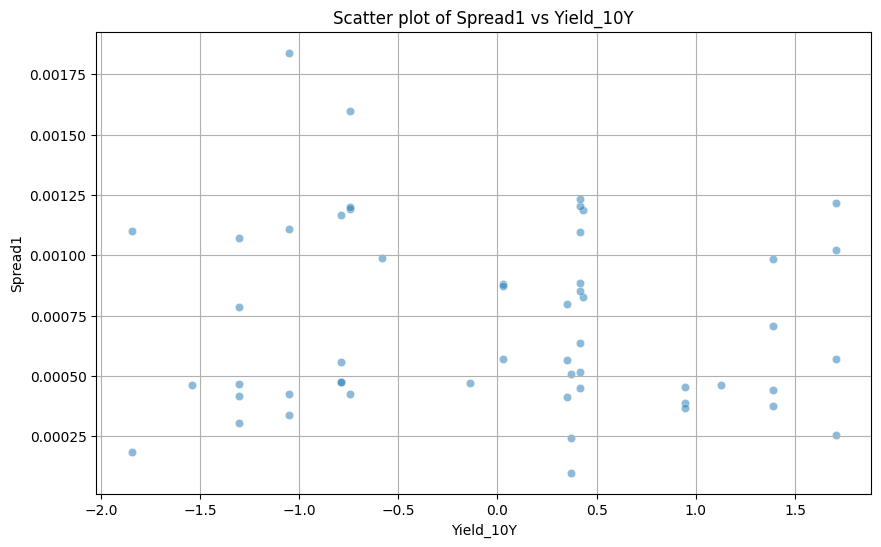

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_scatter_seaborn(data, x_feature, y_feature):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=data[x_feature], y=data[y_feature], alpha=0.5)
    plt.title(f'Scatter plot of {y_feature} vs {x_feature}')
    plt.xlabel(x_feature)
    plt.ylabel(y_feature)
    plt.grid(True)
    plt.show()

plot_scatter_seaborn(data_resampled, 'Yield_10Y', 'Spread1')

In [ ]:
import pandas_datareader as pdr
from datetime import datetime

# Fetch CPI data from FRED (CPIAUCSL - Consumer Price Index for All Urban Consumers)
start_date = datetime(2023, 10, 1)
end_date = datetime(2023, 10, 31)

cpi_data = pdr.get_data_fred('CPIAUCSL', start=start_date, end=end_date)

# Reset index to have the Date column
cpi_data.reset_index(inplace=True)

# Rename the CPI column for easier reference
cpi_data.rename(columns={'CPIAUCSL': 'CPI'}, inplace=True)

print(cpi_data.head())

        DATE      CPI
0 2023-10-01  307.531


In [ ]:
!pip install fredapi

In [ ]:
!pip install pandas_datareader

In [ ]:
import pandas as pd

def data_pipeline(start_date='2023-10-01', end_date='2023-10-31'):
    def data_preprocess(filename):
        rawdata = pd.read_csv(filename)

        if 'TRADETIME' not in rawdata.columns:
            raise KeyError(f"'TRADETIME' column not found in {filename}")

        rawdata = rawdata.loc[rawdata['ACCEPTEDVOL'] != 0]
        rawdata = rawdata[~rawdata['MATURITY_RANGE'].str.contains('Bill|Strip|TRSY FRN|TIPS')]
        rawdata = rawdata.loc[rawdata['TRADETYPE'] == 'OUTRIGHT']

        rawdata.reset_index(inplace=True)
        try:
            rawdata['TIMESTAMP'] = pd.to_datetime(rawdata['TRADETIME'].str.rstrip(' Z'), format='%Y-%m-%d %H:%M:%S.%f')
        except Exception as e:
            raise ValueError(f"Error in parsing 'TRADETIME' in {filename}: {str(e)}")

        rawdata.set_index('TIMESTAMP', inplace=True)
        rawdata.sort_index(inplace=True)
        rawdata['TRADEDATE'] = pd.to_datetime(rawdata['TRADEDATE'], format='%m/%d/%y')
        rawdata['MATURITY_DATE'] = pd.to_datetime(rawdata['MATURITY_DATE'], format='%m/%d/%y')

        return rawdata

    def filter_date_range(df, start_date, end_date):
        return df[(df.index >= start_date) & (df.index <= end_date)]

    # Preprocess trade data from multiple files
    tw1 = data_preprocess('/content/Blockhouse Data 1.csv')
    tw2 = data_preprocess('/content/Blockhouse Data 2.csv')
    tw3 = data_preprocess('/content/Blockhouse Data 3.csv')
    tw4 = data_preprocess('/content/Blockhouse Data 4.csv')
    rawdata = pd.concat([tw1, tw2, tw3, tw4], axis=0)

    # Filter data within the date range
    filtered_rawdata = filter_date_range(rawdata, start_date, end_date)

    return filtered_rawdata

In [ ]:
import pandas_datareader as pdr
import yfinance as yf
from datetime import datetime

# Fetch 5-Year Breakeven Inflation Rate from FRED
def fetch_breakeven_inflation(start_date, end_date):
    breakeven_5y = pdr.get_data_fred('T5YIE', start=start_date, end=end_date)
    return breakeven_5y

# Fetch Yield Curve Data (10-Year and 2-Year) from Yahoo Finance
def fetch_yield_curve_data(start_date, end_date):
    # Fetch 10-Year and 2-Year yields
    yield_10y = yf.download("^TNX", start=start_date, end=end_date, interval="1d")['Adj Close'] / 100  # 10-Year yield
    yield_2y = yf.download("^FVX", start=start_date, end=end_date, interval="1d")['Adj Close'] / 100  # 2-Year yield

    # Fetch the 5-Year Breakeven Inflation Rate from FRED
    breakeven_5y = fetch_breakeven_inflation(start_date, end_date)['T5YIE'] / 100

    # Combine the data into a DataFrame
    yield_data = pd.DataFrame({'Yield_10Y': yield_10y, 'Yield_2Y': yield_2y, 'Breakeven_5Y': breakeven_5y})

    # Resample to minute intervals by forward filling the daily data
    yield_data = yield_data.resample('1min').ffill()

    return yield_data

In [ ]:
def combine_data_with_yield(filtered_rawdata, start_date, end_date):
    # Fetch yield curve data
    yield_data = fetch_yield_curve_data(start_date, end_date)

    # Ensure both dataframes have a proper DatetimeIndex
    filtered_rawdata.index = pd.to_datetime(filtered_rawdata.index)
    yield_data.index = pd.to_datetime(yield_data.index)

    # Merge bond data with yield data on the minute-level timestamp
    filtered_rawdata = filtered_rawdata.merge(yield_data, left_index=True, right_index=True, how='left')

    # Calculate mid price, slippage, and spread
    filtered_rawdata['MID_PRICE'] = (filtered_rawdata['COMP_ASK'] + filtered_rawdata['COMP_BID']) / 2
    filtered_rawdata['SLIPPAGE'] = filtered_rawdata.apply(lambda row: row['PRICE'] - row['MID_PRICE'] if row['SIDE'] == 'BUY' else row['MID_PRICE'] - row['PRICE'], axis=1)
    filtered_rawdata['Spread'] = (filtered_rawdata['COMP_ASK'] - filtered_rawdata['COMP_BID']) / 2
    filtered_rawdata['Spread1'] = (filtered_rawdata['COMP_ASK'] - filtered_rawdata['COMP_BID']) / filtered_rawdata['MID_PRICE']

    # Filter out rows with negative spread values
    filtered_rawdata = filtered_rawdata[filtered_rawdata['Spread'] >= 0]

    return filtered_rawdata

In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import statsmodels.api as sm

# Feature Engineering
def feature_engineering(filtered_rawdata, features, frequency):
    # Calculate volatility (log returns)
    filtered_rawdata['Volatility'] = np.log(filtered_rawdata['PRICE'].pct_change() + 1)

    # Resample data for regression analysis
    data_resampled = filtered_rawdata.resample(frequency).agg({
        'PRICE': 'mean',
        'ACCEPTEDVOL': 'sum',
        'Spread': 'mean',
        'Spread1': 'mean',
        'Volatility': 'std',
        'Yield_10Y': 'mean',
        'Yield_2Y': 'mean',
        'Breakeven_5Y': 'mean'
    })

    # Drop missing values
    data_resampled.dropna(inplace=True)

    # Standardize features
    scaler = StandardScaler()
    for feature in features:
        data_resampled[feature] = scaler.fit_transform(data_resampled[[feature]])

    return data_resampled

# Regression Model
def get_regression_model(data_resampled, features):
    X = data_resampled[features]
    y = data_resampled['Spread1']
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()
    return model

In [ ]:
# Define features
features = ['Volatility', 'ACCEPTEDVOL', 'Yield_10Y', 'Yield_2Y', 'Breakeven_5Y']

# Define date range
start = '2023-10-01'
end = '2023-10-31'

# Run data pipeline
filtered_rawdata = data_pipeline(start_date=start, end_date=end)
combined_data = combine_data_with_yield(filtered_rawdata, start, end)

# Feature engineering with minute-level resampling
data_resampled = feature_engineering(combined_data, features, frequency='1min')

# Run regression
model = get_regression_model(data_resampled, features)
print(model.summary())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


                            OLS Regression Results                            
Dep. Variable:                Spread1   R-squared:                       0.767
Model:                            OLS   Adj. R-squared:                  0.743
Method:                 Least Squares   F-statistic:                     32.21
Date:                Thu, 03 Oct 2024   Prob (F-statistic):           2.18e-14
Time:                        19:06:01   Log-Likelihood:                 395.42
No. Observations:                  55   AIC:                            -778.8
Df Residuals:                      49   BIC:                            -766.8
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.0007   2.61e-05     26.981   

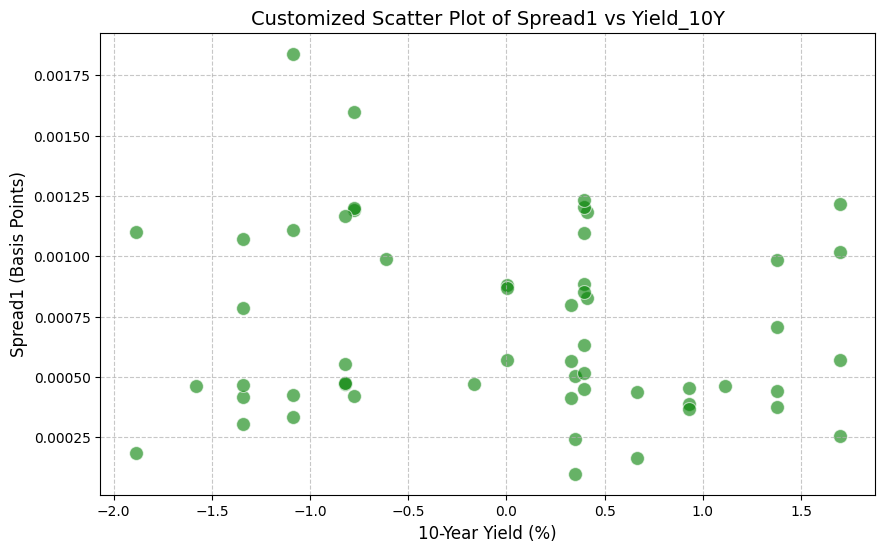

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Enhanced scatter plot using Seaborn with more customization options
def plot_scatter_seaborn(data, x_feature, y_feature, color='blue', marker_size=50, title=None, x_label=None, y_label=None):
    plt.figure(figsize=(10, 6))

    # Scatter plot with optional customization
    sns.scatterplot(
        x=data[x_feature],
        y=data[y_feature],
        color=color,
        s=marker_size,  # Marker size
        alpha=0.6  # Transparency of the markers
    )

    # Add title if provided
    if title:
        plt.title(title, fontsize=14)
    else:
        plt.title(f'Scatter plot of {y_feature} vs {x_feature}', fontsize=14)

    # Add labels to the axes
    plt.xlabel(x_label if x_label else x_feature, fontsize=12)
    plt.ylabel(y_label if y_label else y_feature, fontsize=12)

    # Customize the grid
    plt.grid(True, linestyle='--', alpha=0.7)

    # Add axis limits if necessary (optional)
    # plt.xlim([-2, 2])
    # plt.ylim([0, 1])

    plt.show()

# Example usage:
plot_scatter_seaborn(
    data=data_resampled,
    x_feature='Yield_10Y',
    y_feature='Spread1',
    color='green',  # Customize marker color
    marker_size=100,  # Customize marker size
    title='Customized Scatter Plot of Spread1 vs Yield_10Y',  # Custom title
    x_label='10-Year Yield (%)',  # Custom X-axis label
    y_label='Spread1 (Basis Points)'  # Custom Y-axis label
)

In [ ]:
# Function to filter data by maturity range and perform regression for each maturity range
def regression_by_maturity_range(filtered_rawdata, start_date, end_date, maturity_range, features):
    # Step 1: Filter the data for the specific maturity range
    maturity_filtered_data = filtered_rawdata[filtered_rawdata['MATURITY_RANGE'] == maturity_range]

    # Step 2: Combine filtered bond data with yield data
    combined_data = combine_data_with_yield(maturity_filtered_data, start_date, end_date)

    # Step 3: Perform feature engineering with minute-level resampling
    data_resampled = feature_engineering(combined_data, features, frequency='1min')

    # Step 4: Run regression
    model = get_regression_model(data_resampled, features)

    # Print regression summary
    print(f"Regression results for {maturity_range}:")
    print(model.summary())

# List of features to use in regression
features = ['Volatility', 'ACCEPTEDVOL', 'Yield_10Y', 'Yield_2Y', 'Breakeven_5Y']

# Define date range
start = '2023-10-01'
end = '2023-10-31'

# Run data pipeline
filtered_rawdata = data_pipeline(start_date=start, end_date=end)

# Run regression for each maturity range
maturity_ranges = ['Note 0 - 1.5 Year', 'Note 1.5 - 3.5 Year', 'Note 3.5 - 5.5 Year', 'Note 5.5 - 10 Year', 'Note >10 Year']

# Loop through each maturity range and run regression
for maturity_range in maturity_ranges:
    regression_by_maturity_range(filtered_rawdata, start, end, maturity_range, features)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.10/dist-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  res = hypotest_fun_out(*samples, **kwds)
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Regression results for Note 0 - 1.5 Year:
                            OLS Regression Results                            
Dep. Variable:                Spread1   R-squared:                       0.182
Model:                            OLS   Adj. R-squared:                 -0.159
Method:                 Least Squares   F-statistic:                    0.5343
Date:                Thu, 03 Oct 2024   Prob (F-statistic):              0.747
Time:                        19:55:54   Log-Likelihood:                 155.39
No. Observations:                  18   AIC:                            -298.8
Df Residuals:                      12   BIC:                            -293.4
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const 


/usr/local/lib/python3.10/dist-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=17
  res = hypotest_fun_out(*samples, **kwds)
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Regression results for Note 1.5 - 3.5 Year:
                            OLS Regression Results                            
Dep. Variable:                Spread1   R-squared:                       0.466
Model:                            OLS   Adj. R-squared:                  0.224
Method:                 Least Squares   F-statistic:                     1.922
Date:                Thu, 03 Oct 2024   Prob (F-statistic):              0.170
Time:                        19:55:54   Log-Likelihood:                 135.17
No. Observations:                  17   AIC:                            -258.3
Df Residuals:                      11   BIC:                            -253.4
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
cons


/usr/local/lib/python3.10/dist-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=15
  res = hypotest_fun_out(*samples, **kwds)
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Regression results for Note 3.5 - 5.5 Year:
                            OLS Regression Results                            
Dep. Variable:                Spread1   R-squared:                       0.256
Model:                            OLS   Adj. R-squared:                 -0.157
Method:                 Least Squares   F-statistic:                    0.6207
Date:                Thu, 03 Oct 2024   Prob (F-statistic):              0.688
Time:                        19:55:54   Log-Likelihood:                 116.51
No. Observations:                  15   AIC:                            -221.0
Df Residuals:                       9   BIC:                            -216.8
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
cons


/usr/local/lib/python3.10/dist-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=19
  res = hypotest_fun_out(*samples, **kwds)
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Regression results for Note 5.5 - 10 Year:
                            OLS Regression Results                            
Dep. Variable:                Spread1   R-squared:                       0.326
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     1.259
Date:                Thu, 03 Oct 2024   Prob (F-statistic):              0.338
Time:                        19:55:55   Log-Likelihood:                 148.10
No. Observations:                  19   AIC:                            -284.2
Df Residuals:                      13   BIC:                            -278.5
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const

Regression results for Note >10 Year:
                            OLS Regression Results                            
Dep. Variable:                Spread1   R-squared:                       0.077
Model:                            OLS   Adj. R-squared:                 -0.308
Method:                 Least Squares   F-statistic:                    0.1989
Date:                Thu, 03 Oct 2024   Prob (F-statistic):              0.957
Time:                        19:55:55   Log-Likelihood:                 112.08
No. Observations:                  18   AIC:                            -212.2
Df Residuals:                      12   BIC:                            -206.8
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const     

/usr/local/lib/python3.10/dist-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  res = hypotest_fun_out(*samples, **kwds)
